In [1]:
import os
import re
import shutil
import subprocess
import pandas as pd 
import subprocess
import glob
import nibabel as nib
import numpy as np

In [2]:
def get_oasis_subject_ids(master_csv): 

    master_df = pd.read_csv(master_csv)
    id_col = master_df.columns[0]
    experiments = master_df[id_col]

    subjects = set([ exp.split("_")[0] for exp in experiments])
    return list(subjects)
    

In [3]:
def download_oasis_scans(ids_list, output_dir): 

    df = pd.DataFrame({"image_id":ids_list})
    temp_df_path = os.path.join(output_dir, "temp_" + ids_list[0] + ".csv") 
    df.to_csv(temp_df_path, index=False)

    subprocess.run(["./download_oasis_scans.sh", temp_df_path, output_dir, "T1w"])

    os.remove(temp_df_path)

In [4]:
download_oasis_scans(["OAS30001_MR_d2430"], ".")


Error starting session.  Maybe a bad username/password?


In [ ]:
def preprocess_mri(id, master_folder):

    try:
        # Get mri folder path
        mri_folder = os.path.join(master_folder, id)

        subdir_names = []
        mri_filepath = ""

        for dirpath, dirnames, filenames in os.walk(mri_folder):

            # Save subdir names for later cleanup
            if dirpath == mri_folder:
                subdir_names = dirnames

            # Find first T1w scan 
            for file in filenames: 
                if "T1w" in file and ( file.endswith(".nii") or file.endswith(".nii.gz")):
                    mri_filepath = os.path.join(dirpath, file)
                    break

        # New file name 
        new_path = os.path.join(mri_folder, id + ".nii.gz")

        # Copy it and rename it 
        shutil.copyfile(mri_filepath, new_path)

        # Delete other folders 
        for subdir in subdir_names: 
            shutil.rmtree( os.path.join( mri_folder, subdir) )

        # Preprocess
        subprocess.run(["matlab", "-batch", f"preprocess_mri('{new_path}')"], check=True, env={
            "PATH": "/software/matlab-2023a-el8-x86_64/bin:/home/cestari/.conda/envs/adni_rcc/bin:/software/python-anaconda-2022.05-el8-x86_64/condabin:/home/cestari/.vscode-server/data/User/globalStorage/github.copilot-chat/debugCommand:/home/cestari/.vscode-server/data/User/globalStorage/github.copilot-chat/copilotCli:/home/cestari/.vscode-server/bin/94e8ae2b28cb5cc932b86e1070569c4463565c37/bin/remote-cli:/project/aereditato/cestari/fsl/share/fsl/bin:/project/aereditato/cestari/fsl/share/fsl/bin:/home/cestari/.local/bin:/home/cestari/bin:/software/bin:/software/slurm-current-el8-x86_64/bin:/software/modules/bin:/usr/local/bin:/usr/bin:/usr/local/sbin:/usr/sbin:/opt/thinlinc/bin:/home/cestari/.vscode-server/extensions/ms-python.debugpy-2025.18.0-linux-x64/bundled/scripts/noConfigScripts",
            "SPM_PATH": "/project/aereditato/cestari/spm/spm"})

    except Exception as e:
        print(f"MRI preprocessing failed for {id}: {repr(e)}. Exiting.")
        
        # Delete folder if it exists
        if os.path.exists(mri_folder):
            shutil.rmtree(mri_folder)

        return None
        



In [13]:
preprocess_mri("OAS30002_MR_d0371", ".")



------------------------------------------------------------------------
16-Mar-2026 11:20:35 - Running job #1
------------------------------------------------------------------------
16-Mar-2026 11:20:35 - Running 'Segment'

SPM25: spm_preproc_run                             11:20:35 - 16/03/2026
Segment /project/aereditato/cestari/adni-mri-classification/data/preprocessing_multimodal/scripts/OAS30002_MR_d0371/OAS30002_MR_d0371.nii,1
Completed                               :          11:25:31 - 16/03/2026
16-Mar-2026 11:25:31 - Done    'Segment'
16-Mar-2026 11:25:31 - Done



------------------------------------------------------------------------
16-Mar-2026 11:25:37 - Running job #1
------------------------------------------------------------------------
16-Mar-2026 11:25:37 - Running 'Normalise: Write'
16-Mar-2026 11:25:38 - Done    'Normalise: Write'
16-Mar-2026 11:25:38 - Done



------------------------------------------------------------------------
16-Mar-2026 11:25:42 - Run

In [22]:
import nibabel as nib
import matplotlib.pyplot as plt

In [29]:
img = nib.load("./OAS30002_AV45_d2340/pet1/sub-OAS30002_ses-d2340_acq-AV45_pet.nii.gz")

In [30]:
vol = img.get_fdata()

In [41]:
vol = vol.mean(axis=3)

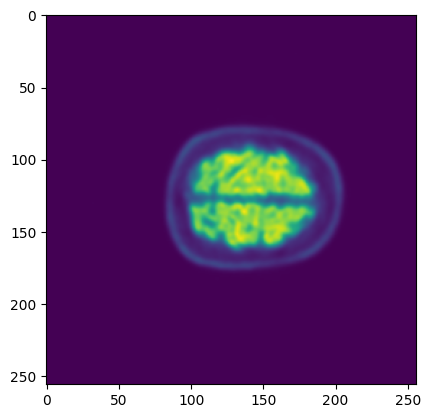

In [53]:
plt.imshow(vol[:,:,85])

In [52]:
nib.save( nib.Nifti1Image(vol, affine=np.eye(4)), "./test.nii")

In [ ]:
def preprocess_pet(pet_id, bias_corr_path, def_field_path, brain_mask_path, master_folder):

    try:

         # Get mri folder path
        pet_folder = os.path.join(master_folder, pet_id)

        subdir_names = []
        pet_filepath = ""

        for dirpath, dirnames, filenames in os.walk(pet_folder):

            # Save subdir names for later cleanup
            if dirpath == pet_folder:
                subdir_names = dirnames

            # Find first .nii file
            for file in filenames: 
                if ( file.endswith(".nii") or file.endswith(".nii.gz")):
                    pet_filepath = os.path.join(dirpath, file)
                    break

        # New file name 
        new_path = os.path.join(pet_folder, pet_id + ".nii.gz")

        # Copy it and rename it 
        shutil.copyfile(pet_filepath, new_path)

        # Delete other folders 
        for subdir in subdir_names: 
            print(f"Removing {subdir}")
            shutil.rmtree( os.path.join( pet_folder, subdir) )
        
        # Run matlab preprocessing script
        subprocess.run(["matlab", "-batch", f"preprocess_pet('{pet_folder}','{bias_corr_path}', '{def_field_path}', '{brain_mask_path}')"], check=True, env={
            "PATH": "/software/matlab-2023a-el8-x86_64/bin:/home/cestari/.conda/envs/adni_rcc/bin:/software/python-anaconda-2022.05-el8-x86_64/condabin:/home/cestari/.vscode-server/data/User/globalStorage/github.copilot-chat/debugCommand:/home/cestari/.vscode-server/data/User/globalStorage/github.copilot-chat/copilotCli:/home/cestari/.vscode-server/bin/94e8ae2b28cb5cc932b86e1070569c4463565c37/bin/remote-cli:/project/aereditato/cestari/fsl/share/fsl/bin:/project/aereditato/cestari/fsl/share/fsl/bin:/home/cestari/.local/bin:/home/cestari/bin:/software/bin:/software/slurm-current-el8-x86_64/bin:/software/modules/bin:/usr/local/bin:/usr/bin:/usr/local/sbin:/usr/sbin:/opt/thinlinc/bin:/home/cestari/.vscode-server/extensions/ms-python.debugpy-2025.18.0-linux-x64/bundled/scripts/noConfigScripts",
            "SPM_PATH": "/project/aereditato/cestari/spm/spm"})
        
        # Get name of produced .nii file
        nii = glob.glob(os.path.join(pet_folder, "*.nii"))
    
        # Rename it to clean_w_masked_rstatic_ID.nii
        filename = os.path.join(pet_folder, 'clean_w_masked_rstatic_' + pet_id + ".nii")
        os.replace(nii[0], filename)
        
    except Exception as e:
        print(f"PET preprocessing failed for {pet_id}: {repr(e)}. Skipping.")
        
        # Remove PET folder if it was created 
        if os.path.exists(pet_folder):
            shutil.rmtree(pet_folder)

In [31]:

def_field_path = "./OAS30002_MR_d0371/y_OAS30002_MR_d0371.nii"
bias_corr_path = "./OAS30002_MR_d0371/mOAS30002_MR_d0371.nii"
brain_mask_path = "./OAS30002_MR_d0371/brain_mask_pet_mOAS30002_MR_d0371.nii"

In [32]:
preprocess_pet("OAS30002_PIB_d2345", bias_corr_path, def_field_path ,brain_mask_path, ".")

Removing pet1
Static PET written to:
  ./OAS30002_PIB_d2345/static_OAS30002_PIB_d2345.nii


------------------------------------------------------------------------
16-Mar-2026 18:11:10 - Running job #1
------------------------------------------------------------------------
16-Mar-2026 18:11:10 - Running 'Coregister: Estimate & Reslice'

SPM25: spm_coreg                                   18:11:10 - 16/03/2026
Completed                               :          18:11:19 - 16/03/2026

SPM25: spm_reslice                                 18:11:19 - 16/03/2026
Completed                               :          18:11:21 - 16/03/2026
16-Mar-2026 18:11:21 - Done    'Coregister: Estimate & Reslice'
16-Mar-2026 18:11:21 - Done



------------------------------------------------------------------------
16-Mar-2026 18:11:26 - Running job #1
------------------------------------------------------------------------
16-Mar-2026 18:11:26 - Running 'Normalise: Write'
16-Mar-2026 18:11:28 - Done    'Norma